In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# EDA:

In [ ]:
data = pd.read_csv("insurance.csv")

In [ ]:
df = data.copy()
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
((df.isnull().sum() / len(df)) * 100)[df.isnull().sum() > 0]

,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


## visualize 1 feature

In [ ]:
df['expenses'].skew()

np.float64(1.5153909165486397)

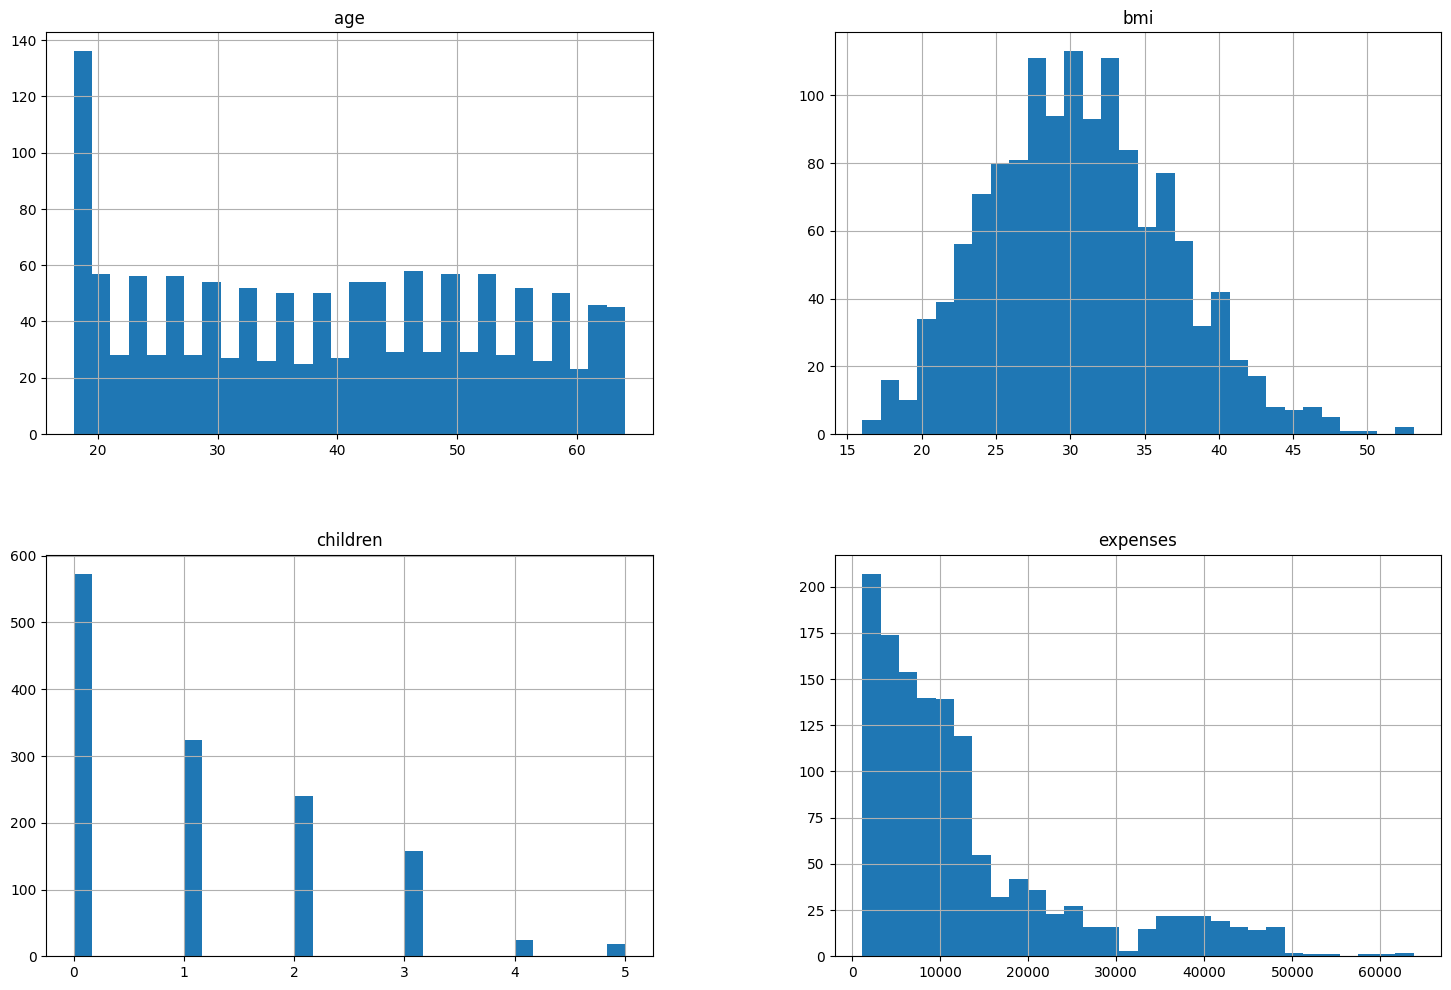

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"])

num_cols.hist(
    figsize=(18, 12),
    bins=30
)

plt.show()

- Age: Shows a nearly uniform distribution with a noticeable peak in the young adult age group (approx. 18–20 years old).

- BMI: Follows a normal distribution with the majority of values centered around 30.

- Children: Most individuals in the dataset have no children, with a gradual decrease in frequency as the number of children increases.

- Expenses: Right-skewed distribution; most expenses are clustered at the lower end, with a small tail of individuals having very high medical costs.

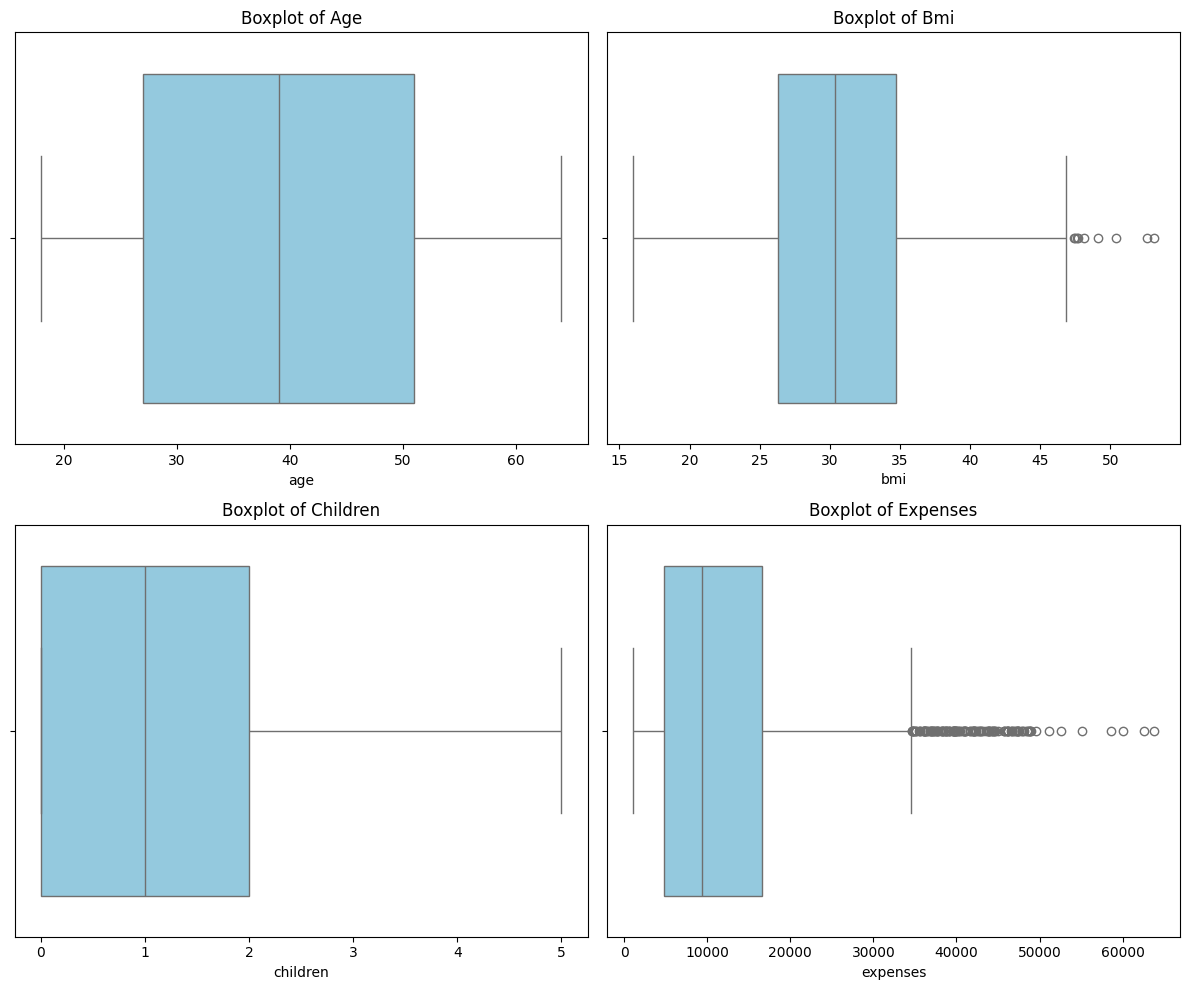

In [ ]:
num_cols_list = ['age', 'bmi', 'children', 'expenses']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_list):
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col.capitalize()}', fontsize=12)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

- Age & Children: No outliers.

- BMI: Some outliers are present on the upper end (individuals with very high BMI).

- Expenses: Numerous outliers on the upper end, suggesting specific cases with exceptionally high medical costs.

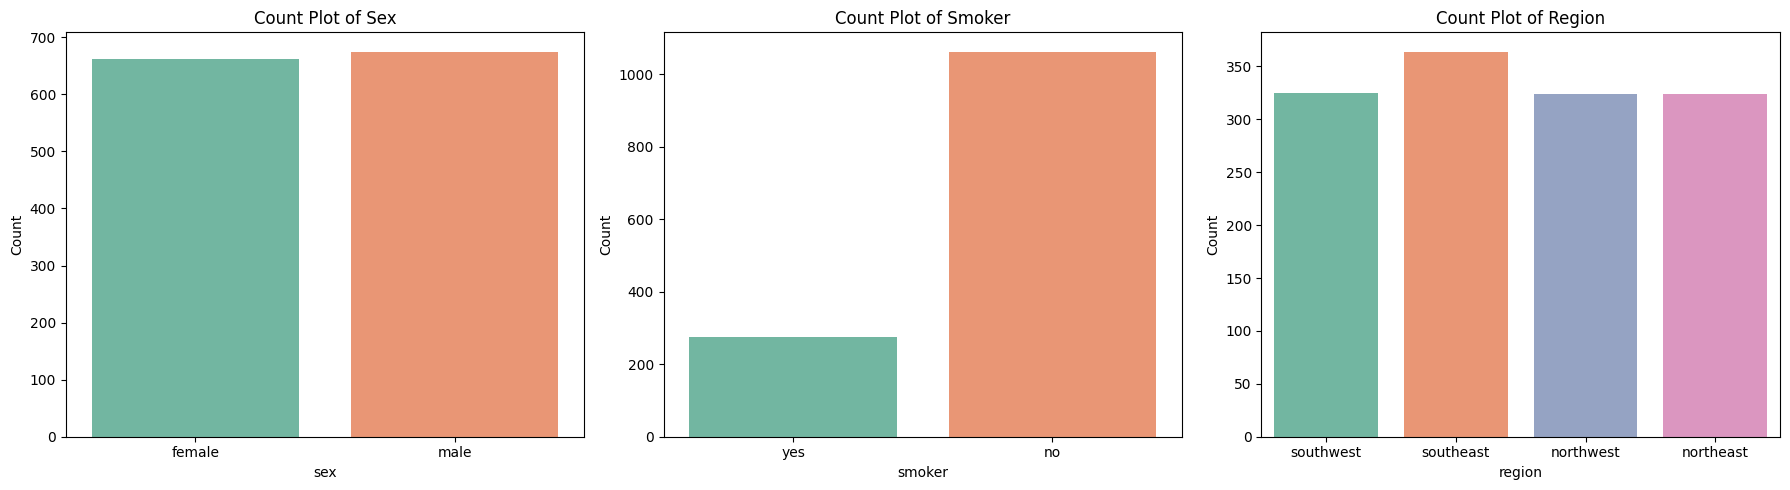

In [ ]:
obj_cols = df.select_dtypes(include=["object"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(obj_cols):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Count Plot of {col.capitalize()}', fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

- Sex: The distribution is very balanced between males and females.

- Smoker: The vast majority of the sample are non-smokers.

- Region: The distribution is roughly equal across the four geographical regions.

## visualize 2 featurese

### Numercial columns VS Target column (expenses)

In [ ]:
corr = num_cols.corr()
corr

,age,bmi,children,expenses
age,1.000000,0.109414,0.041536,0.298308
bmi,0.109414,1.000000,0.012641,0.198637
children,0.041536,0.012641,1.000000,0.067389
expenses,0.298308,0.198637,0.067389,1.000000


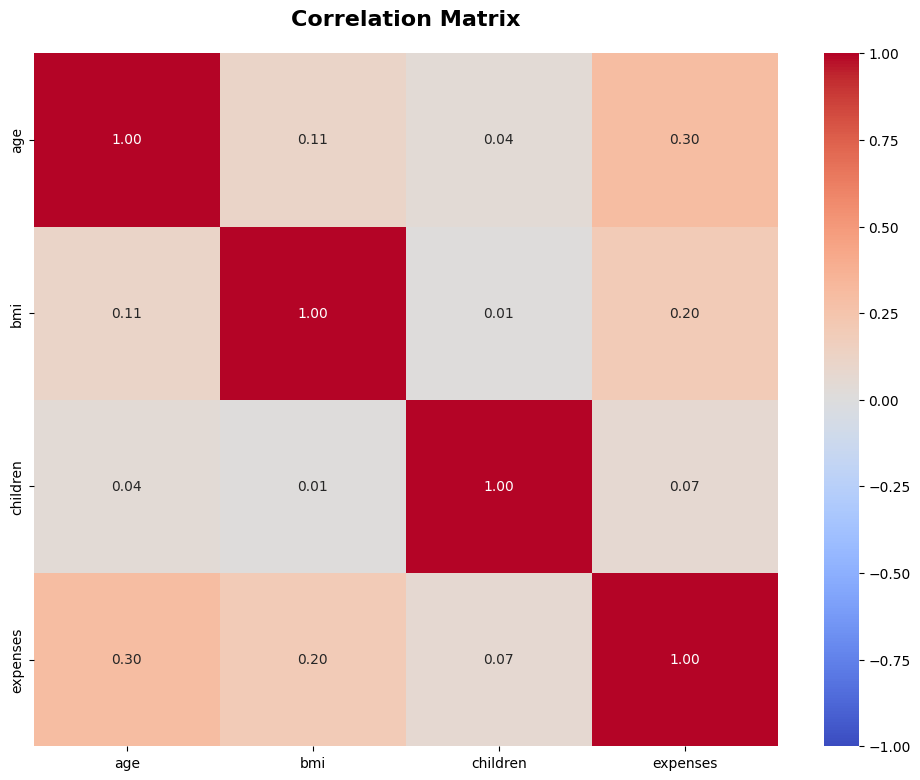

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.show()

- There is a moderate positive correlation between Age and Expenses (0.30).

- There is a weak positive correlation between BMI and Expenses (0.20).

- There are no strong correlations between other continuous variables.

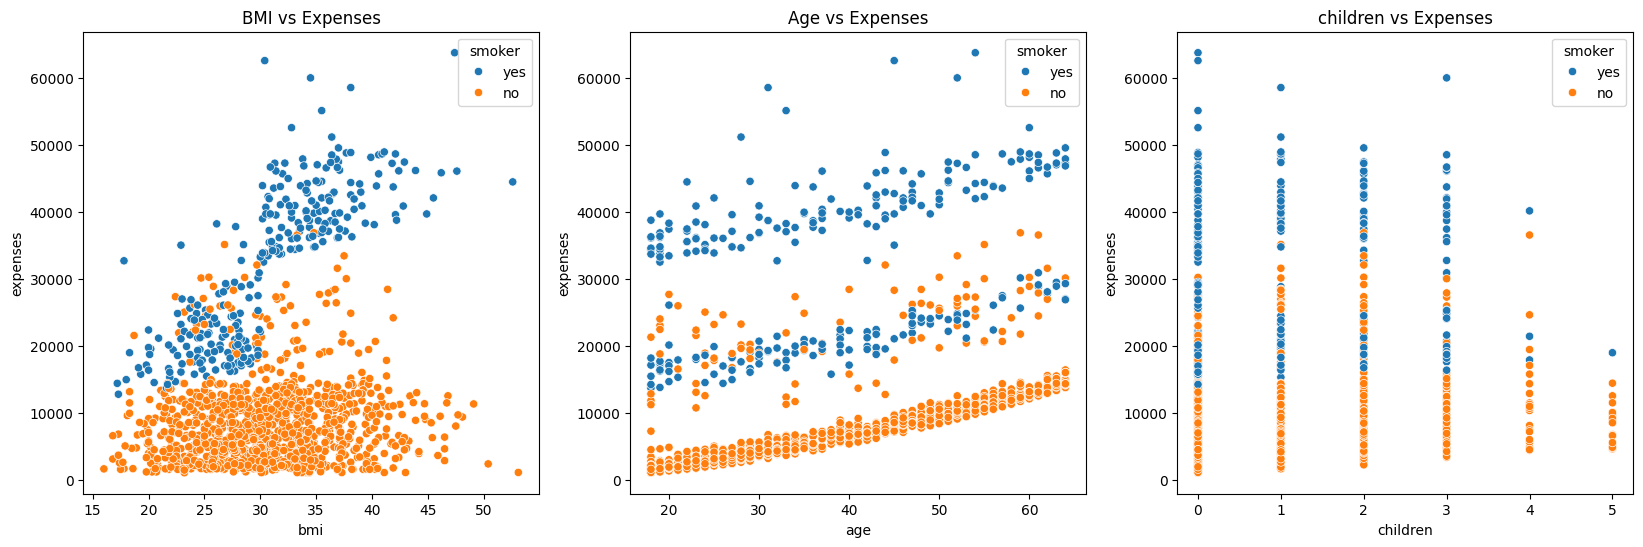

In [ ]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df['bmi'], y=df['expenses'], hue=df['smoker'])
plt.title('BMI vs Expenses')

plt.subplot(1, 3, 2)
sns.scatterplot(x=df['age'], y=df['expenses'], hue=df['smoker'])
plt.title('Age vs Expenses')

plt.subplot(1, 3, 3)
sns.scatterplot(x=df['children'], y=df['expenses'], hue=df['smoker'])
plt.title('children vs Expenses')

plt.show()

- BMI vs. Expenses: Clearly shows that smokers (blue dots) have significantly higher expenses compared to non-smokers, especially as BMI increases.

- Age vs. Expenses: Reveals distinct parallel paths; smokers consistently have higher costs regardless of age, with costs generally trending upward as age increases.

- Children vs. Expenses: No clear linear relationship is evident, but smokers remain at a higher cost level across all child-count categories.

### Categorical columns VS Categorical columns

In [ ]:
pd.crosstab(df["sex"], df["smoker"])

smoker,no,yes
sex,,
female,547,115
male,516,159


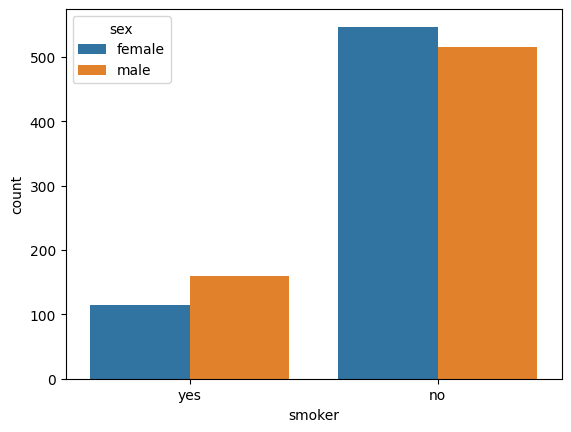

In [ ]:
sns.countplot(x="smoker", hue="sex", data=df)
plt.show()

- Non-Smokers: This group represents the vast majority of the dataset, with a higher count of females than males.

- Smokers: This is the smaller group in the dataset, and it contains a higher count of males compared to females.

### Categorical columns VS Target column (expenses)

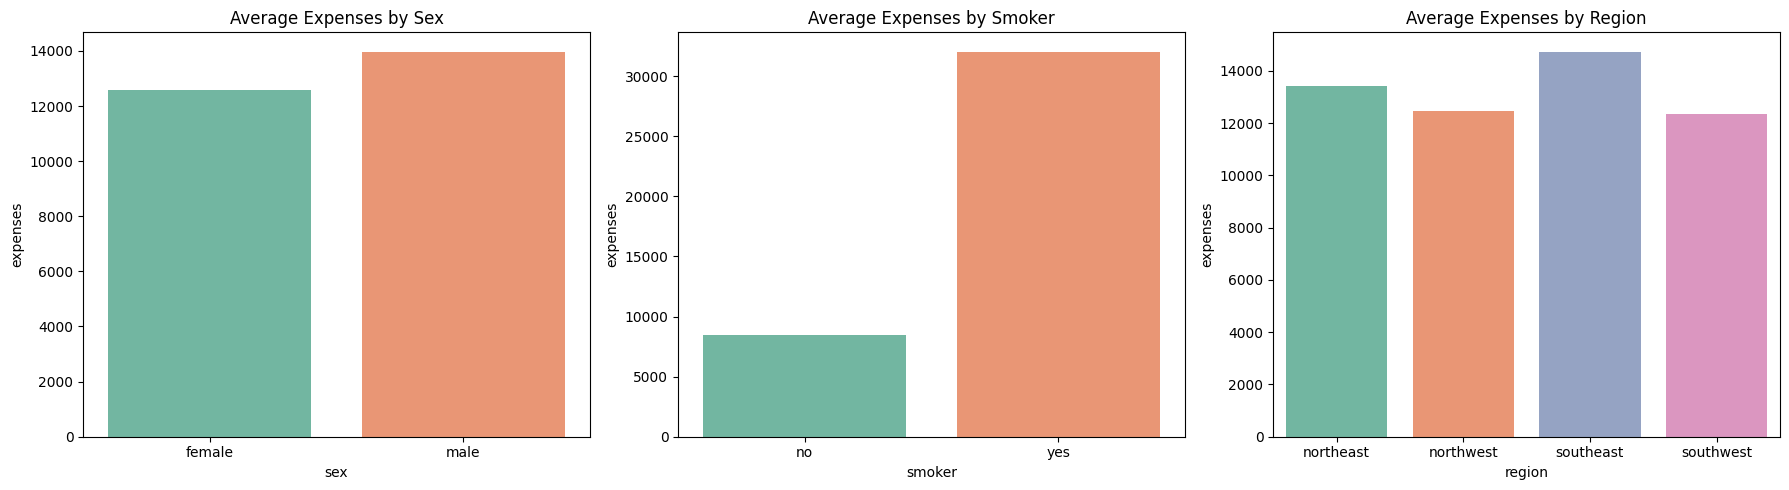

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(obj_cols):
    n_mean = df.groupby(col)["expenses"].mean().reset_index()
    sns.barplot(data=n_mean, x=col, y="expenses",  hue=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Average Expenses by {col.capitalize()}', fontsize=12)
    axes[i].set_ylabel('expenses')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

- Sex: Average expenses for males are slightly higher than for females.

- Smoker: Average expense for smokers is multiple times higher than for non-smokers.

- Region: There is slight variation, with the "southeast" region recording the highest average costs.

# Data Prepocessing

In [ ]:
# Features and Target

X = df.drop("expenses", axis=1)
y = df["expenses"]

In [ ]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.9,0,yes,southwest
1,18,male,33.8,1,no,southeast
2,28,male,33.0,3,no,southeast
3,33,male,22.7,0,no,northwest
4,32,male,28.9,0,no,northwest


In [ ]:
y.head()

,expenses
0,16884.92
1,1725.55
2,4449.46
3,21984.47
4,3866.86


### Encoding Categorical Variables

The categorical features (sex, smoker, and region) were converted into numerical values using One-Hot Encoding. This transformation allows the Random Forest Regression model to process categorical data correctly.

In [ ]:
# Encode categorical variables

X = pd.get_dummies(X, drop_first=True)

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,False,True,False,False,True
1,18,33.8,1,True,False,False,True,False
2,28,33.0,3,True,False,False,True,False
3,33,22.7,0,True,False,True,False,False
4,32,28.9,0,True,False,True,False,False


### Train-Test Split

The dataset was split into training and testing sets. The training set (80%) was used to train the model, while the testing set (20%) was used to evaluate its performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1069, 8)
Testing Features: (268, 8)
Training Target: (1069,)
Testing Target: (268,)


### Feature Scaling

Feature scaling was not applied because Random Forest Regression is a tree-based algorithm that is not affected by the scale of the input features. Therefore, scaling is not required for this model.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200,max_depth=None,random_state=42,n_jobs=-1)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*45)
print("Random Forest:")
print("="*45)
print(f" Mean Absolute Error (MAE)      : {mae:.2f}")
print(f" Mean Squared Error (MSE)       : {mse:.2f}")
print(f" Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f" R² Score                       : {r2:.4f}")
print("="*45)

Random Forest:
 Mean Absolute Error (MAE)      : 2627.26
 Mean Squared Error (MSE)       : 21810412.28
 Root Mean Squared Error (RMSE) : 4670.16
 R² Score                       : 0.8813
